In [137]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


In [138]:
words = open('names.txt', 'r').read().splitlines()
len(words)

32033

In [139]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [140]:
block_size = 3
X, Y = [], []

for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ----> e
..e ----> m
.em ----> m
emm ----> a
mma ----> .
olivia
... ----> o
..o ----> l
.ol ----> i
oli ----> v
liv ----> i
ivi ----> a
via ----> .
ava
... ----> a
..a ----> v
.av ----> a
ava ----> .
isabella
... ----> i
..i ----> s
.is ----> a
isa ----> b
sab ----> e
abe ----> l
bel ----> l
ell ----> a
lla ----> .
sophia
... ----> s
..s ----> o
.so ----> p
sop ----> h
oph ----> i
phi ----> a
hia ----> .


In [141]:
X.shape

torch.Size([32, 3])

In [142]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [143]:
C = torch.randn(27,2)

In [144]:
for idx in range(len(C)):
    print(C[idx])
    print(itos[idx])

tensor([ 1.2861, -0.1942])
.
tensor([ 0.9625, -0.5206])
a
tensor([-1.4133, -0.4216])
b
tensor([1.0606, 2.8050])
c
tensor([-0.8312,  0.7463])
d
tensor([0.8925, 0.0686])
e
tensor([ 0.2983, -0.0903])
f
tensor([-1.3386,  0.5108])
g
tensor([-1.4496,  0.2586])
h
tensor([-0.6432, -0.9332])
i
tensor([-1.7558,  0.9288])
j
tensor([-0.3901,  0.0113])
k
tensor([ 0.2820, -1.1422])
l
tensor([-0.8620,  0.4017])
m
tensor([-0.7518, -0.3737])
n
tensor([ 1.5703, -0.2730])
o
tensor([-0.8133, -0.1186])
p
tensor([-1.7795,  0.6927])
q
tensor([0.3897, 1.2573])
r
tensor([ 0.8881, -1.6208])
s
tensor([ 1.0979, -0.4802])
t
tensor([-0.2700, -0.2116])
u
tensor([ 0.3403, -1.7611])
v
tensor([ 1.4505, -0.3851])
w
tensor([-0.3464,  0.5164])
x
tensor([-0.1197, -0.4845])
y
tensor([1.0148, 0.5305])
z


In [145]:
C[X]

tensor([[[ 1.2861, -0.1942],
         [ 1.2861, -0.1942],
         [ 1.2861, -0.1942]],

        [[ 1.2861, -0.1942],
         [ 1.2861, -0.1942],
         [ 0.8925,  0.0686]],

        [[ 1.2861, -0.1942],
         [ 0.8925,  0.0686],
         [-0.8620,  0.4017]],

        [[ 0.8925,  0.0686],
         [-0.8620,  0.4017],
         [-0.8620,  0.4017]],

        [[-0.8620,  0.4017],
         [-0.8620,  0.4017],
         [ 0.9625, -0.5206]],

        [[ 1.2861, -0.1942],
         [ 1.2861, -0.1942],
         [ 1.2861, -0.1942]],

        [[ 1.2861, -0.1942],
         [ 1.2861, -0.1942],
         [ 1.5703, -0.2730]],

        [[ 1.2861, -0.1942],
         [ 1.5703, -0.2730],
         [ 0.2820, -1.1422]],

        [[ 1.5703, -0.2730],
         [ 0.2820, -1.1422],
         [-0.6432, -0.9332]],

        [[ 0.2820, -1.1422],
         [-0.6432, -0.9332],
         [ 0.3403, -1.7611]],

        [[-0.6432, -0.9332],
         [ 0.3403, -1.7611],
         [-0.6432, -0.9332]],

        [[ 0.3403, -1

In [146]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [147]:
W1 = torch.rand(6,100)
b1 = torch.rand(100)

In [148]:
torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]], 1).shape

torch.Size([32, 6])

In [149]:
torch.cat(torch.unbind(emb, 1),1).shape

torch.Size([32, 6])

In [150]:
h = (emb.view(-1,6)) @ W1 + b1
#h = (emb.view(32,6)) @ W1 + b1
#h = (emb.view(emb.shape[0],6)) @ W1 + b1

W1.shape == 32,100

B1.shape == 100

32,100

1 ,100

broadcastable because each column has either equal values, 1, or DNE value

(emb.view(32,6)) @ W1 + b1 == (emb.view(-1,6)) @ W1 + b1 == (emb.view(emb.shape[0],6)) @ W1 + b1


In [151]:
h = torch.tanh(h)

In [152]:
W2 = torch.rand(100,27)
B2 = torch.rand(27)

In [153]:
logits = h @ W2 + B2

In [154]:
logits.shape

torch.Size([32, 27])

In [155]:
counts = logits.exp()

In [156]:
prob = counts/counts.sum(1,keepdims=True)

In [157]:
prob.shape

torch.Size([32, 27])

In [158]:
prob

tensor([[9.7132e-07, 3.2300e-07, 5.0544e-05, 3.1640e-04, 2.7079e-03, 1.3803e-05,
         2.2205e-02, 1.3279e-05, 1.4851e-06, 1.8381e-04, 1.7309e-02, 3.9445e-05,
         5.1648e-06, 1.0616e-06, 7.8455e-04, 8.2187e-05, 6.4195e-07, 2.3818e-07,
         8.8734e-06, 3.2264e-04, 1.9056e-03, 4.4010e-04, 5.0202e-05, 2.9633e-06,
         2.2483e-04, 7.7018e-01, 1.8315e-01],
        [1.0643e-06, 3.5668e-07, 5.2911e-05, 3.4719e-04, 3.1012e-03, 1.3943e-05,
         2.4511e-02, 1.3895e-05, 1.6914e-06, 2.2348e-04, 1.9448e-02, 4.1207e-05,
         5.6417e-06, 1.0040e-06, 8.1780e-04, 8.8641e-05, 6.7667e-07, 2.4032e-07,
         9.8194e-06, 3.4013e-04, 2.1385e-03, 4.5096e-04, 5.0766e-05, 3.1203e-06,
         2.2668e-04, 7.5281e-01, 1.9530e-01],
        [1.0015e-05, 4.2519e-06, 2.5815e-04, 2.5696e-03, 5.0852e-03, 3.4598e-05,
         2.5247e-02, 6.5131e-05, 3.0700e-05, 2.2062e-03, 3.8000e-02, 2.1407e-04,
         5.3020e-05, 6.3543e-06, 2.6227e-03, 4.2594e-04, 9.1438e-06, 2.8409e-06,
         5.6977e-

In [159]:
prob[0].sum()

tensor(1.0000)

In [160]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(7.2697)

In [161]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

# Cleaned Version 1

In [162]:
block_size = 3
X, Y = [], []

for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [169]:
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [170]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g, requires_grad=True)
W1 = torch.randn((6,100), generator=g, requires_grad=True)
b1 = torch.randn(100, generator=g, requires_grad=True)
W2 = torch.randn((100,27), generator=g, requires_grad=True)
b2 = torch.randn(27,generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]


In [171]:
sum(p.nelement() for p in parameters)

3481

In [172]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [173]:
lri = []
lossi = []

for i in range(1000):
    #minibatch construct
    ix = torch.randint(0, X.shape[0],(32,))
    #forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Y[ix])
    lossi.append(loss.item())
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

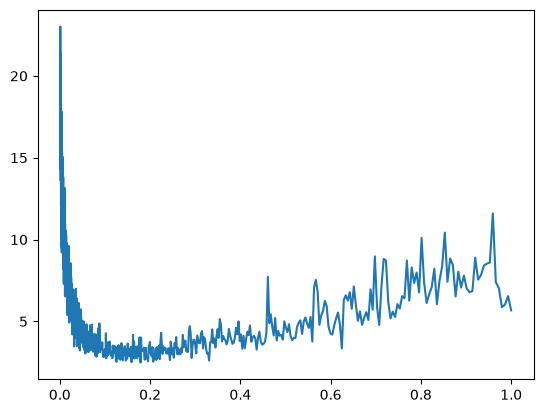

In [174]:
plt.plot(lrs,lossi)